# E13 — Gambar naskah dan pemeriksaan angka camera-ready

Notebook ini tidak menjalankan solver dan tidak membuat data baru. Semua isinya dibaca dari
CSV yang sudah tersimpan di folder `results/`, lalu dipakai untuk dua hal: membangun ulang
Gambar 1 naskah, dan mencocokkan setiap angka yang dikutip di naskah terhadap artefaknya.

Kita jalankan notebook ini setiap kali angka di naskah disentuh, supaya tidak ada nilai yang
hidup hanya di dalam berkas `.tex`.


## 1. Persiapan

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

RESULTS = Path("results")          # ubah kalau struktur folder kita berbeda
OUT     = Path("results")          # gambar hasil disimpan di sini

BERKAS = ["E12_anomaly_summary.csv", "E12_E9J_tests.csv", "E12b_table1.csv",
          "E12_E9J_summary_all.csv", "E12_E9J_summary_clear.csv", "E12_E9J_summary_cloudy.csv",
          "E12b_E11_summary.csv", "E12_E9J_summary_all.csv", "E12_E9J_raw.csv",
          "E12_TF_heldout_raw.csv", "E9_raw.csv", "E12_residuals_3day.npz"]

ada   = [b for b in dict.fromkeys(BERKAS) if (RESULTS / b).exists()]
hilang = [b for b in dict.fromkeys(BERKAS) if not (RESULTS / b).exists()]

print(f"Berkas ditemukan : {len(ada)}")
for b in ada:
    print("  -", b)
if hilang:
    print(f"\nBerkas tidak ditemukan ({len(hilang)}), sel berikutnya yang memakainya akan dilewati:")
    for b in hilang:
        print("  -", b)
else:
    print("\nSeluruh berkas yang dibutuhkan tersedia.")

Berkas ditemukan : 11
  - E12_anomaly_summary.csv
  - E12_E9J_tests.csv
  - E12b_table1.csv
  - E12_E9J_summary_all.csv
  - E12_E9J_summary_clear.csv
  - E12_E9J_summary_cloudy.csv
  - E12b_E11_summary.csv
  - E12_E9J_raw.csv
  - E12_TF_heldout_raw.csv
  - E9_raw.csv
  - E12_residuals_3day.npz

Seluruh berkas yang dibutuhkan tersedia.


## 2. Gambar 1 naskah

Panel (a) memuat RMSE setahun penuh untuk empat metode dari 20 mask. Panel (b) memuat margin
STMAC terhadap klimatologi pada sepuluh mask bersama, dipisah menurut kondisi langit. Penanda
kosong menandai selisih yang tidak signifikan setelah koreksi Holm.

Ukuran gambar dibuat sama dengan lebar teks IEEEtran A4 dua kolom, yaitu sekitar 7,16 inci,
sehingga ukuran huruf di gambar tidak berubah lagi saat dimasukkan ke naskah.

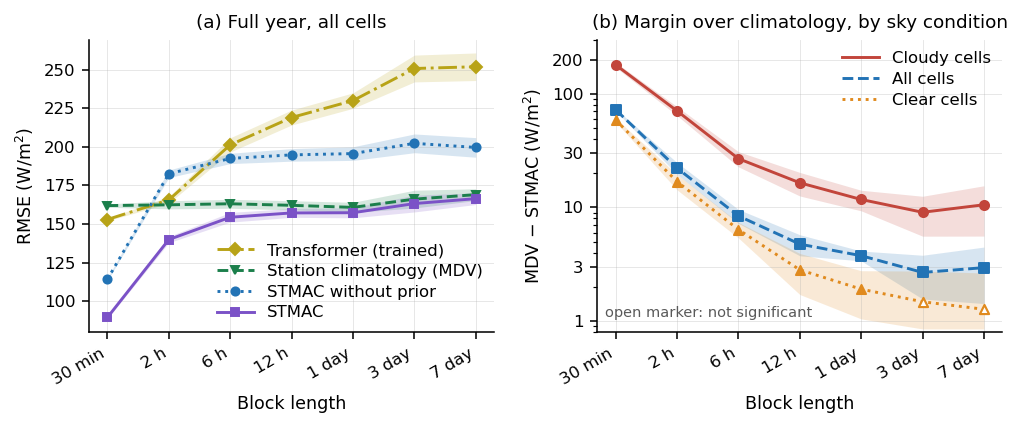

Tersimpan: /Users/user/Desktop/Proyek lomba paper/Project KFUPM/Final 5/stmac-demo 2/notebooks/results/fig_block_sweep.png


In [2]:
ORDER = ["30 min", "2 h", "6 h", "12 h", "1 day", "3 day", "7 day"]

S = pd.read_csv(RESULTS / "E12_anomaly_summary.csv").set_index("label").loc[ORDER].reset_index()
T = pd.read_csv(RESULTS / "E12_E9J_tests.csv")
x = np.arange(len(ORDER))

plt.rcParams.update({
    "font.size": 9, "axes.titlesize": 9.5, "axes.labelsize": 9,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "axes.grid": True, "grid.alpha": 0.30, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 140,
})

fig, (a1, a2) = plt.subplots(1, 2, figsize=(7.16, 2.95))

SERI = [("transformer",     "Transformer (trained)",     "#B8A317", "-.", "D"),
        ("climatology",     "Station climatology (MDV)", "#1B7F4B", "--", "v"),
        ("joint_longitude", "STMAC without prior",       "#2273B5", ":",  "o"),
        ("anomaly",         "STMAC",                     "#7B52C7", "-",  "s")]
for kol, lab, c, ls, mk in SERI:
    a1.fill_between(x, S[kol + "_lo"], S[kol + "_hi"], color=c, alpha=0.18, lw=0)
    a1.plot(x, S[kol], ls, color=c, marker=mk, ms=4.2, lw=1.5, label=lab)
a1.set_xticks(x); a1.set_xticklabels(ORDER, rotation=30, ha="right")
a1.set_ylabel(r"RMSE (W/m$^2$)"); a1.set_xlabel("Block length")
a1.set_title("(a) Full year, all cells")
a1.legend(loc="lower right", frameon=False, handlelength=2.2, borderpad=0.2, labelspacing=0.35)

LANGIT = [("cloudy", "Cloudy cells", "#C2453B", "-",  "o"),
          ("all",    "All cells",    "#2273B5", "--", "s"),
          ("clear",  "Clear cells",  "#E08A1E", ":",  "^")]
for sub, lab, c, ls, mk in LANGIT:
    d = T[(T.a == "climatology") & (T.b == "anomaly") & (T.subset == sub)].set_index("label").loc[ORDER]
    a2.fill_between(x, d.ci_lo.clip(lower=0.85), d.ci_hi, color=c, alpha=0.18, lw=0)
    a2.plot(x, d.mean_diff, ls, color=c, lw=1.5, zorder=3, label=lab)
    sig = (d.p_holm < 0.05).values
    a2.scatter(x[sig],  d.mean_diff.values[sig],  marker=mk, s=22, color=c, zorder=4)
    a2.scatter(x[~sig], d.mean_diff.values[~sig], marker=mk, s=22, facecolors="white",
               edgecolors=c, linewidths=1.1, zorder=4)
a2.set_yscale("log"); a2.set_ylim(0.8, 300)
a2.set_xticks(x); a2.set_xticklabels(ORDER, rotation=30, ha="right")
a2.set_ylabel(r"MDV $-$ STMAC (W/m$^2$)"); a2.set_xlabel("Block length")
a2.set_title("(b) Margin over climatology, by sky condition")
a2.set_yticks([1, 3, 10, 30, 100, 200]); a2.set_yticklabels(["1", "3", "10", "30", "100", "200"])
a2.legend(loc="upper right", frameon=False, handlelength=2.2, borderpad=0.2, labelspacing=0.35)
a2.text(0.02, 0.05, "open marker: not significant", transform=a2.transAxes, fontsize=7.5, color="0.35")

fig.tight_layout(pad=0.4, w_pad=1.6)
fig.savefig(OUT / "fig_block_sweep.png", dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
print("Tersimpan:", (OUT / "fig_block_sweep.png").resolve())

### Pembacaan otomatis Gambar 1

In [3]:
def baca_gambar():
    baris = []
    m30 = S.loc[S.label == "30 min"].iloc[0]
    m7d = S.loc[S.label == "7 day"].iloc[0]
    baris.append(f"Panel (a): RMSE STMAC naik dari {m30.anomaly:.1f} W/m2 pada blok 30 menit "
                 f"ke {m7d.anomaly:.1f} W/m2 pada blok 7 hari, sementara klimatologi bergerak dari "
                 f"{m30.climatology:.1f} ke {m7d.climatology:.1f} W/m2.")
    menang = S[S.anomaly < S.climatology].label.tolist()
    baris.append(f"Panel (a): STMAC lebih rendah dari klimatologi di {len(menang)} dari {len(S)} "
                 f"panjang blok ({', '.join(menang)}).")
    for sub, nama in [("cloudy", "berawan"), ("all", "semua"), ("clear", "cerah")]:
        d = T[(T.a == "climatology") & (T.b == "anomaly") & (T.subset == sub)].set_index("label").loc[ORDER]
        ns = list(d.index[d.p_holm >= 0.05])
        baris.append(f"Panel (b), sel {nama}: margin {d.mean_diff.min():.1f} sampai "
                     f"{d.mean_diff.max():.1f} W/m2, rata-rata {d.mean_diff.mean():.1f} W/m2; "
                     + (f"tidak signifikan pada {', '.join(ns)}." if ns
                        else f"signifikan di seluruh panjang blok (p Holm maksimum {d.p_holm.max():.4f})."))
    return baris

print("PEMBACAAN GAMBAR 1")
print("=" * 88)
for b in baca_gambar():
    print("-", b)

PEMBACAAN GAMBAR 1
- Panel (a): RMSE STMAC naik dari 89.6 W/m2 pada blok 30 menit ke 166.5 W/m2 pada blok 7 hari, sementara klimatologi bergerak dari 162.0 ke 169.1 W/m2.
- Panel (a): STMAC lebih rendah dari klimatologi di 7 dari 7 panjang blok (30 min, 2 h, 6 h, 12 h, 1 day, 3 day, 7 day).
- Panel (b), sel berawan: margin 9.1 sampai 180.1 W/m2, rata-rata 46.5 W/m2; signifikan di seluruh panjang blok (p Holm maksimum 0.0137).
- Panel (b), sel semua: margin 2.7 sampai 72.5 W/m2, rata-rata 16.7 W/m2; signifikan di seluruh panjang blok (p Holm maksimum 0.0137).
- Panel (b), sel cerah: margin 1.3 sampai 58.9 W/m2, rata-rata 12.8 W/m2; tidak signifikan pada 3 day, 7 day.


## 3. Tabel II naskah dan model biaya

Basis harga memakai rata-rata tujuh panjang blok, bukan satu blok tunggal. Kolom terakhir
membatasi evaluasi pada sel berawan.

In [4]:
HD, EPS, RATED = 4380, 0.10, 1000.0        # jam siang per tahun, fraksi kekosongan, W/m2

def biaya(P_gw, rmse_wm2, tarif_usd_mwh, eps=EPS, hd=HD):
    """Biaya galat tahunan dalam juta USD, Persamaan (7) naskah."""
    return P_gw * (rmse_wm2 / RATED) * eps * hd * tarif_usd_mwh * 1000 / 1e6

T1 = pd.read_csv(RESULTS / "E12b_table1.csv")
KB = pd.read_csv(RESULTS / "E12_E9J_summary_cloudy.csv")
CR = pd.read_csv(RESULTS / "E12_E9J_summary_clear.csv")
AL = pd.read_csv(RESULTS / "E12_E9J_summary_all.csv")

BASIS = {"PT": T1.pure_temporal.mean(), "MDV": T1.climatology.mean(),
         "TF": T1.transformer.mean(),   "STMAC": T1.anomaly.mean()}
MARGIN_BERAWAN = KB.climatology.mean() - KB.anomaly.mean()

SKENARIO = [("40 GW, $3/MWh", 40.0, 3.0), ("52.7 GW, $5/MWh", 52.7, 5.0),
            ("52.7 GW, $10/MWh", 52.7, 10.0)]

rows = []
for nama, P, c in SKENARIO:
    v = {k: biaya(P, r, c) for k, r in BASIS.items()}
    rows.append({"Skenario": nama, "PT": v["PT"], "MDV": v["MDV"], "TF": v["TF"],
                 "STMAC": v["STMAC"], "d_TF": v["TF"] - v["STMAC"],
                 "d_MDV": v["MDV"] - v["STMAC"], "d_MDV_berawan": biaya(P, MARGIN_BERAWAN, c)})
TAB2 = pd.DataFrame(rows).set_index("Skenario").round(1)

print("Basis RMSE rata-rata tujuh blok (W/m2):")
for k, r in BASIS.items():
    print(f"  {k:6s} {r:8.2f}")
print(f"\nMargin MDV dikurangi STMAC: semua {AL.climatology.mean()-AL.anomaly.mean():5.2f} | "
      f"cerah {CR.climatology.mean()-CR.anomaly.mean():5.2f} | berawan {MARGIN_BERAWAN:5.2f} W/m2")
print("\nTABEL II (juta USD per tahun)")
print(TAB2.to_string())

Basis RMSE rata-rata tujuh blok (W/m2):
  PT      1208.63
  MDV      163.69
  TF       210.18
  STMAC    146.90

Margin MDV dikurangi STMAC: semua 16.74 | cerah 12.80 | berawan 46.51 W/m2

TABEL II (juta USD per tahun)
                     PT   MDV    TF  STMAC  d_TF  d_MDV  d_MDV_berawan
Skenario                                                              
40 GW, $3/MWh      63.5   8.6  11.0    7.7   3.3    0.9            2.4
52.7 GW, $5/MWh   139.5  18.9  24.3   17.0   7.3    1.9            5.4
52.7 GW, $10/MWh  279.0  37.8  48.5   33.9  14.6    3.9           10.7


### Pembacaan otomatis Tabel II

In [5]:
print("PEMBACAAN TABEL II")
print("=" * 88)
print(f"- Biaya galat STMAC berkisar ${TAB2.STMAC.min():.1f} juta sampai ${TAB2.STMAC.max():.1f} "
      f"juta per tahun pada tiga skenario.")
print(f"- Terhadap Transformer, STMAC lebih murah ${TAB2.d_TF.min():.1f} juta sampai "
      f"${TAB2.d_TF.max():.1f} juta per tahun.")
print(f"- Terhadap klimatologi, selisihnya ${TAB2.d_MDV.min():.1f} juta sampai "
      f"${TAB2.d_MDV.max():.1f} juta per tahun pada seluruh sel, dan "
      f"${TAB2.d_MDV_berawan.min():.1f} juta sampai ${TAB2.d_MDV_berawan.max():.1f} juta "
      f"bila dibatasi pada sel berawan.")
lipat = TAB2.d_MDV_berawan / TAB2.d_MDV
print(f"- Pembatasan pada sel berawan memperbesar selisih terhadap klimatologi "
      f"{lipat.min():.1f} kali.")
tiga = T1.loc[T1.label == "3 day"].iloc[0]
print(f"- Sebagai pembanding, memakai blok 3 hari saja margin terhadap klimatologi hanya "
      f"{tiga.climatology - tiga.anomaly:.2f} W/m2, "
      f"setara ${biaya(52.7, tiga.climatology - tiga.anomaly, 5.0):.2f} juta pada skenario 52,7 GW dan $5/MWh.")

PEMBACAAN TABEL II
- Biaya galat STMAC berkisar $7.7 juta sampai $33.9 juta per tahun pada tiga skenario.
- Terhadap Transformer, STMAC lebih murah $3.3 juta sampai $14.6 juta per tahun.
- Terhadap klimatologi, selisihnya $0.9 juta sampai $3.9 juta per tahun pada seluruh sel, dan $2.4 juta sampai $10.7 juta bila dibatasi pada sel berawan.
- Pembatasan pada sel berawan memperbesar selisih terhadap klimatologi 2.7 kali.
- Sebagai pembanding, memakai blok 3 hari saja margin terhadap klimatologi hanya 2.88 W/m2, setara $0.33 juta pada skenario 52,7 GW dan $5/MWh.


## 4. Pemeriksaan angka naskah

Setiap nilai yang ditulis di naskah kita bandingkan dengan artefaknya. Status `COCOK` berarti
selisihnya di bawah toleransi pembulatan.

In [6]:
PERIKSA = []   # (keterangan, nilai di naskah, nilai hitung, toleransi)

# Tabel II
for (nama, P, c), harap in zip(SKENARIO, [[63.5, 8.6, 11.0, 7.7, 3.3, 0.9, 2.4],
                                          [139.5, 18.9, 24.3, 17.0, 7.3, 1.9, 5.4],
                                          [279.0, 37.8, 48.5, 33.9, 14.6, 3.9, 10.7]]):
    got = TAB2.loc[nama].tolist()
    for kol, a, b in zip(TAB2.columns, got, harap):
        PERIKSA.append((f"Tabel II {nama} {kol}", b, a, 0.06))

# Klaim di teks
tt = T[(T.a == "climatology") & (T.b == "anomaly")]
cld = tt[tt.subset == "cloudy"].set_index("label").loc[ORDER]
clr = tt[tt.subset == "clear"].set_index("label").loc[ORDER]
PERIKSA += [("margin berawan minimum",  9.1,   cld.mean_diff.min(), 0.06),
            ("margin berawan maksimum", 180.1, cld.mean_diff.max(), 0.06),
            ("margin cerah minimum",    1.3,   clr.mean_diff.min(), 0.06),
            ("margin cerah maksimum",   58.9,  clr.mean_diff.max(), 0.06)]

# Tabel I setahun penuh
for lab, kol, harap in [("30 min", "anomaly", 89.6), ("3 day", "anomaly", 163.3),
                        ("7 day", "anomaly", 166.5), ("30 min", "climatology", 162.0),
                        ("30 min", "transformer", 153.0), ("7 day", "pure_temporal", 4961.2)]:
    PERIKSA.append((f"Tabel I {lab} {kol}", harap, T1.loc[T1.label == lab, kol].iat[0], 0.06))

# Jaringan satelit
S11 = pd.read_csv(RESULTS / "E12b_E11_summary.csv")
for N, harap in [(11, 77.8), (25, 72.5), (50, 66.5)]:
    PERIKSA.append((f"E11 STMAC N={N}", harap, S11[S11.N == N].rmse_anomaly_cvN.mean(), 0.06))
s50 = S11[S11.N == 50]
PERIKSA.append(("E11 margin N=50", 21.4, (s50.rmse_climatology - s50.rmse_anomaly_cvN).mean(), 0.06))

# Basis held-out (jawaban atas periode latih Transformer)
HO = {k: T1[v].mean() for k, v in [("MDV","climatology_heldout"),
                                   ("TF","transformer_heldout"),
                                   ("S","anomaly_heldout")]}
FY = {"MDV": T1.climatology.mean(), "TF": T1.transformer.mean(), "S": T1.anomaly.mean()}
for k, harap in [("MDV",0.59), ("TF",0.59), ("S",0.61)]:
    PERIKSA.append((f"rasio held-out/setahun {k}", harap, HO[k]/FY[k], 0.006))
PERIKSA += [("dTF held-out 40GW/$3",   1.8, biaya(40,   HO["TF"]-HO["S"],  3.0), 0.06),
            ("dTF held-out 52.7/$10",  7.9, biaya(52.7, HO["TF"]-HO["S"], 10.0), 0.06),
            ("dMDV held-out 40GW/$3",  0.4, biaya(40,   HO["MDV"]-HO["S"], 3.0), 0.06),
            ("dMDV held-out 52.7/$10", 1.7, biaya(52.7, HO["MDV"]-HO["S"],10.0), 0.06)]

# Kurva nilai marginal per stasiun pada lapangan satelit
def nilai_sat(N):
    d = S11[S11.N == N]
    return biaya(52.7, (d.rmse_climatology - d.rmse_anomaly_cvN).mean(), 10.0)
v11, v25, v50 = nilai_sat(11), nilai_sat(25), nilai_sat(50)
PERIKSA += [("satelit N=11 @52.7/$10", 3.5, v11, 0.06),
            ("satelit N=50 @52.7/$10", 5.0, v50, 0.06),
            ("marginal 11->25 (k$/sts)", 69.0, 1e3*(v25-v11)/14, 1.0),
            ("marginal 25->50 (k$/sts)", 21.0, 1e3*(v50-v25)/25, 1.0)]

# Komposisi sel dan laju kekosongan
E9R = pd.read_csv(RESULTS / "E9_raw.csv")      # memuat n_eval, n_clear, n_cloudy
if "n_cloudy" in E9R.columns:
    PERIKSA.append(("fraksi sel berawan (%)", 11.7, 100 * E9R.n_cloudy.sum() / E9R.n_eval.sum(), 0.1))

print(f"{'ANGKA':<34}{'NASKAH':>10}{'ARTEFAK':>12}   STATUS")
print("=" * 88)
gagal = 0
for ket, naskah, hitung, tol in PERIKSA:
    st = "COCOK" if abs(float(hitung) - naskah) <= tol else "BEDA"
    gagal += st == "BEDA"
    print(f"{ket:<34}{naskah:>10.1f}{float(hitung):>12.2f}   {st}")
print("=" * 88)
print(f"{len(PERIKSA) - gagal} dari {len(PERIKSA)} angka cocok." if gagal == 0
      else f"PERHATIAN: {gagal} dari {len(PERIKSA)} angka tidak cocok, periksa baris berstatus BEDA.")

ANGKA                                 NASKAH     ARTEFAK   STATUS
Tabel II 40 GW, $3/MWh PT               63.5       63.50   COCOK
Tabel II 40 GW, $3/MWh MDV               8.6        8.60   COCOK
Tabel II 40 GW, $3/MWh TF               11.0       11.00   COCOK
Tabel II 40 GW, $3/MWh STMAC             7.7        7.70   COCOK
Tabel II 40 GW, $3/MWh d_TF              3.3        3.30   COCOK
Tabel II 40 GW, $3/MWh d_MDV             0.9        0.90   COCOK
Tabel II 40 GW, $3/MWh d_MDV_berawan       2.4        2.40   COCOK
Tabel II 52.7 GW, $5/MWh PT            139.5      139.50   COCOK
Tabel II 52.7 GW, $5/MWh MDV            18.9       18.90   COCOK
Tabel II 52.7 GW, $5/MWh TF             24.3       24.30   COCOK
Tabel II 52.7 GW, $5/MWh STMAC          17.0       17.00   COCOK
Tabel II 52.7 GW, $5/MWh d_TF            7.3        7.30   COCOK
Tabel II 52.7 GW, $5/MWh d_MDV           1.9        1.90   COCOK
Tabel II 52.7 GW, $5/MWh d_MDV_berawan       5.4        5.40   COCOK
Tabel II 52.7 GW, 

## 5. Pemeriksaan dua klaim yang mudah terlewat

Yang pertama adalah ambang tarif tiered pada model biaya, yang di naskah harus tertulis 15
persen sesuai `d2=0.15` di kode. Yang kedua adalah laju kekosongan nyata pada rekaman 1999,
yang menjadi dasar kalimat bahwa epsilon adalah parameter skenario.

In [7]:
def agg_tiered(e, d1=0.05, d2=0.15, m1=1.0, m2=1.5):
    a = np.abs(e) / RATED
    w = np.where(a <= d1, 0.0, np.where(a <= d2, m1 * (a - d1), m1 * (d2 - d1) + m2 * (a - d2)))
    return float(np.mean(w) * RATED)

npz = RESULTS / "E12_residuals_3day.npz"
if npz.exists():
    z = np.load(npz)
    for k in ["anomaly", "climatology"]:
        e = z[k].ravel()
        t15, t20 = agg_tiered(e), agg_tiered(e, m2=2.0)
        print(f"{k:12s} RMSE {np.sqrt(np.mean(e**2)):7.2f} | tier 1,5x {t15:7.2f} | "
              f"tier 2,0x {t20:7.2f} | kenaikan {100*(t20/t15-1):5.1f}%")
    print("\nAmbang tarif atas pada kode adalah d2 = 0.15, jadi naskah harus menulis 15 persen.")
else:
    print("E12_residuals_3day.npz tidak ada, pemeriksaan tiered dilewati.")

par = Path("data/multistation_1999_full.parquet")
if par.exists():
    X = pd.read_parquet(par)
    X = X.mask(X >= 9900.0)
    hilang, total = int(X.isna().sum().sum()), int(X.size)
    print(f"\nRekaman 1999: {hilang:,} dari {total:,} sel stasiun hilang "
          f"({100*hilang/total:.2f}%). Naskah memakai epsilon = {EPS:.2f}, "
          f"yaitu {EPS/(hilang/total):.0f} kali laju itu, sehingga epsilon memang harus "
          f"disebut parameter skenario.")
else:
    print("\ndata/multistation_1999_full.parquet tidak ada, pemeriksaan epsilon dilewati.")

anomaly      RMSE  160.51 | tier 1,5x   79.61 | tier 2,0x   95.31 | kenaikan  19.7%
climatology  RMSE  162.64 | tier 1,5x   81.21 | tier 2,0x   97.47 | kenaikan  20.0%

Ambang tarif atas pada kode adalah d2 = 0.15, jadi naskah harus menulis 15 persen.

Rekaman 1999: 3,606 dari 1,156,320 sel stasiun hilang (0.31%). Naskah memakai epsilon = 0.10, yaitu 32 kali laju itu, sehingga epsilon memang harus disebut parameter skenario.


## 6. Ringkasan

Sel di bawah mencetak ringkasan yang bisa langsung dibandingkan dengan isi naskah.

In [8]:
print("RINGKASAN UNTUK NASKAH")
print("=" * 88)
print(f"Gambar 1  : {(OUT / 'fig_block_sweep.png').name}, dua panel, lebar 7,16 inci, 400 dpi.")
print(f"Tabel II  : biaya STMAC ${TAB2.STMAC.min():.1f}M sampai ${TAB2.STMAC.max():.1f}M per tahun; "
      f"selisih terhadap Transformer ${TAB2.d_TF.min():.1f}M sampai ${TAB2.d_TF.max():.1f}M; "
      f"terhadap klimatologi ${TAB2.d_MDV.min():.1f}M sampai ${TAB2.d_MDV.max():.1f}M, "
      f"dan ${TAB2.d_MDV_berawan.min():.1f}M sampai ${TAB2.d_MDV_berawan.max():.1f}M pada sel berawan.")
print(f"Bagian V-F: pada sel berawan margin {cld.mean_diff.min():.1f} sampai {cld.mean_diff.max():.1f} W/m2, "
      f"menang {int(cld.wins_b.min())} sampai {int(cld.wins_b.max())} dari {int(cld.n.iloc[0])} mask, "
      f"p Holm maksimum {cld.p_holm.max():.4f}.")
print(f"            pada sel cerah margin {clr.mean_diff.min():.1f} sampai {clr.mean_diff.max():.1f} W/m2, "
      f"tidak signifikan pada {', '.join(clr.index[clr.p_holm >= 0.05])}.")
print(f"Bagian V-G: margin terhadap klimatologi pada N=50 adalah "
      f"{(s50.rmse_climatology - s50.rmse_anomaly_cvN).mean():.1f} W/m2.")
print(f"Status    : {'seluruh angka cocok dengan artefak.' if gagal == 0 else str(gagal) + ' angka tidak cocok.'}")

RINGKASAN UNTUK NASKAH
Gambar 1  : fig_block_sweep.png, dua panel, lebar 7,16 inci, 400 dpi.
Tabel II  : biaya STMAC $7.7M sampai $33.9M per tahun; selisih terhadap Transformer $3.3M sampai $14.6M; terhadap klimatologi $0.9M sampai $3.9M, dan $2.4M sampai $10.7M pada sel berawan.
Bagian V-F: pada sel berawan margin 9.1 sampai 180.1 W/m2, menang 9 sampai 10 dari 10 mask, p Holm maksimum 0.0137.
            pada sel cerah margin 1.3 sampai 58.9 W/m2, tidak signifikan pada 3 day, 7 day.
Bagian V-G: margin terhadap klimatologi pada N=50 adalah 21.4 W/m2.
Status    : seluruh angka cocok dengan artefak.
